# Visualizing the discrete wavelet modules in `fcwt2`

This notebook is a companion to the CWT visualization notebook. It focuses on the newer discrete wavelet APIs:

- wavelet packet transform: recursively splits approximation and detail bands
- stationary wavelet transform: keeps every level aligned to the original signal length
- dual-tree complex wavelet transform: returns complex highpass bands with magnitude and phase

All examples use a power-of-two signal length because the current Rust APIs validate that requirement.

## Setup

Uncomment the install line if you are running this in a fresh notebook environment.

In [1]:
%pip install -q fcwt2 numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.4/741.4 kB 13.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import fcwt2

plt.rcParams.update(
    {
        "figure.figsize": (12, 4),
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

(
    fcwt2.WaveletPacketTransform(2),
    fcwt2.StationaryWaveletTransform(2),
    fcwt2.DualTreeComplexWaveletTransform(2),
)

(WaveletPacketTransform(levels=2),
 StationaryWaveletTransform(levels=2),
 DualTreeComplexWaveletTransform(levels=2))

## A compact test signal

The signal below combines a low-frequency tone, a short high-frequency burst, and a step-like transient. That gives the three transforms something visible to separate across time and scale.

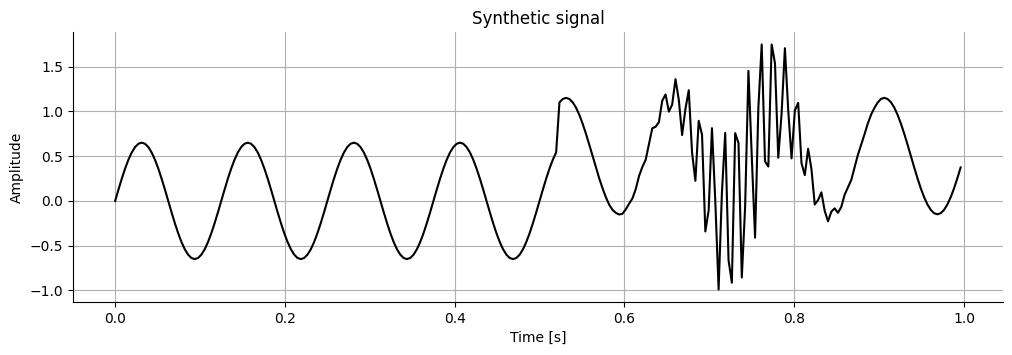

In [3]:
sample_rate = 256
n = 256
t = np.arange(n) / sample_rate

low_tone = 0.65 * np.sin(2 * np.pi * 8.0 * t)
step = 0.5 * (t >= 0.52)
burst_window = np.exp(-0.5 * ((t - 0.74) / 0.045) ** 2)
burst = 1.1 * burst_window * np.sin(2 * np.pi * 70.0 * t)
signal = (low_tone + step + burst).astype(np.float32)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(t, signal, color="black", lw=1.5)
ax.set(title="Synthetic signal", xlabel="Time [s]", ylabel="Amplitude")
plt.show()

In [4]:
def max_abs_error(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return float(np.max(np.abs(a - b)))


def plot_reconstruction(original, reconstructed, title):
    original = np.asarray(original, dtype=float)
    reconstructed = np.asarray(reconstructed, dtype=float)
    error = reconstructed - original

    fig, axes = plt.subplots(
        2, 1, figsize=(12, 5), sharex=True, constrained_layout=True
    )
    axes[0].plot(t, original, color="black", lw=1.4, label="Original")
    axes[0].plot(
        t, reconstructed, color="tab:orange", lw=1.0, ls="--", label="Reconstructed"
    )
    axes[0].set(title=f"{title} reconstruction", ylabel="Amplitude")
    axes[0].legend(loc="upper left")
    axes[1].plot(t, error, color="tab:red", lw=1.0)
    axes[1].set(
        title=f"Max absolute error = {max_abs_error(original, reconstructed):.2e}",
        xlabel="Time [s]",
        ylabel="Error",
    )
    plt.show()


def heatmap(ax, matrix, title, *, yticklabels=None, cmap="magma"):
    image = ax.imshow(matrix, aspect="auto", interpolation="nearest", cmap=cmap)
    ax.set(title=title, xlabel="Coefficient index")
    if yticklabels is not None:
        ax.set_yticks(np.arange(len(yticklabels)))
        ax.set_yticklabels(yticklabels)
    return image

## Wavelet packet transform

A wavelet packet tree decomposes both approximation and detail branches. At level 4, this produces 16 leaf packets. The path labels use `a` for approximation and `d` for detail.

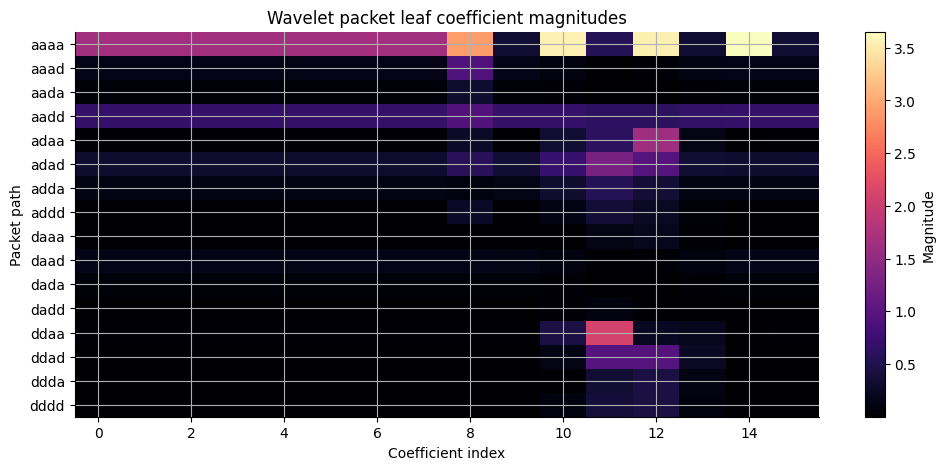

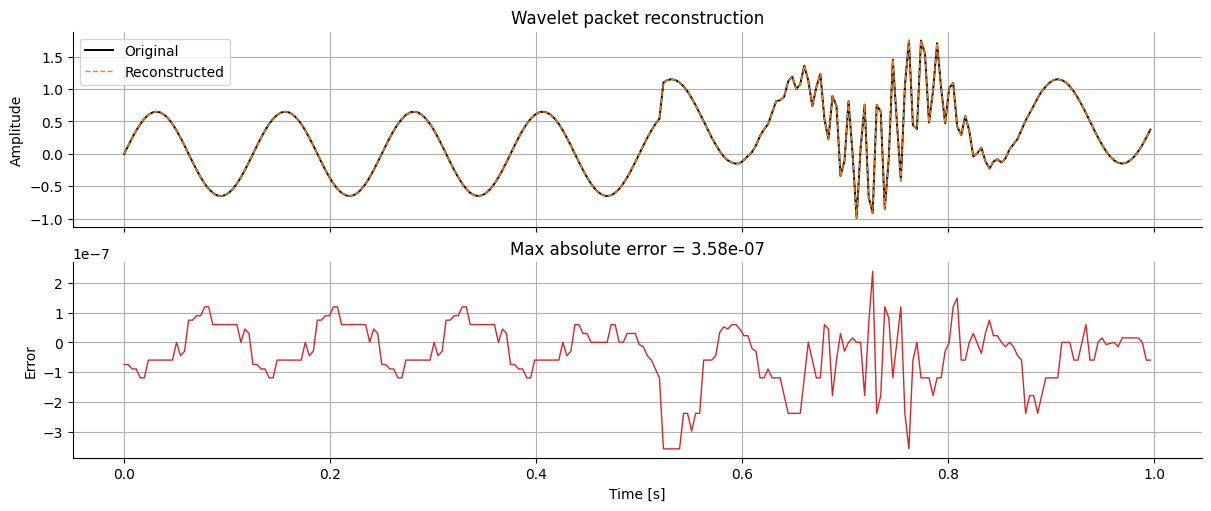

In [5]:
packet = fcwt2.WaveletPacketTransform(4)
packet_tree = packet.decompose(signal.tolist())
packet_leaves = packet_tree.leaves()

packet_matrix = np.asarray([leaf.coefficients for leaf in packet_leaves], dtype=float)
packet_labels = ["".join(leaf.path) for leaf in packet_leaves]

fig, ax = plt.subplots(figsize=(12, 5))
image = heatmap(
    ax,
    np.abs(packet_matrix),
    "Wavelet packet leaf coefficient magnitudes",
    yticklabels=packet_labels,
)
ax.set_ylabel("Packet path")
fig.colorbar(image, ax=ax, label="Magnitude")
plt.show()

packet_reconstructed = np.asarray(packet_tree.reconstruct(), dtype=float)
plot_reconstruction(signal, packet_reconstructed, "Wavelet packet")

## Stationary wavelet transform

The stationary wavelet transform is redundant: approximation and detail arrays stay the same length as the input at every level. That makes it useful for locating transients without the downsampling shifts of a critically sampled DWT.

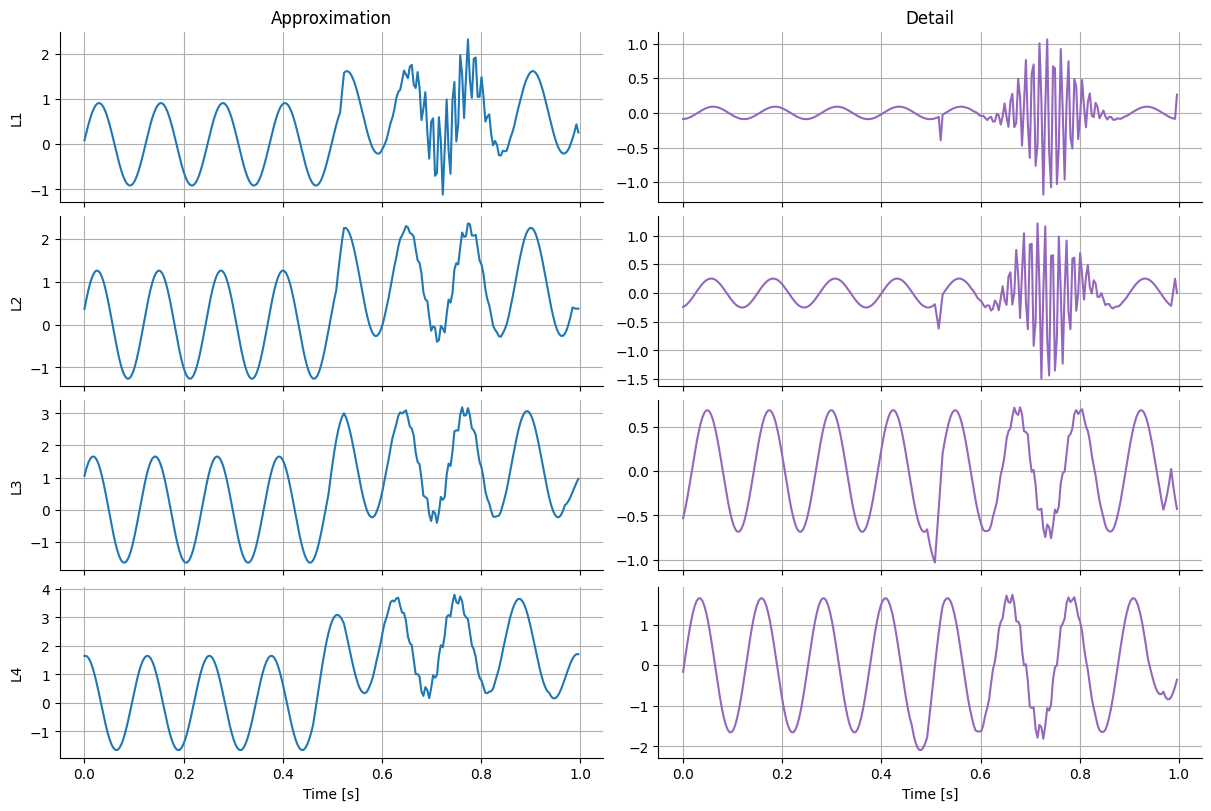

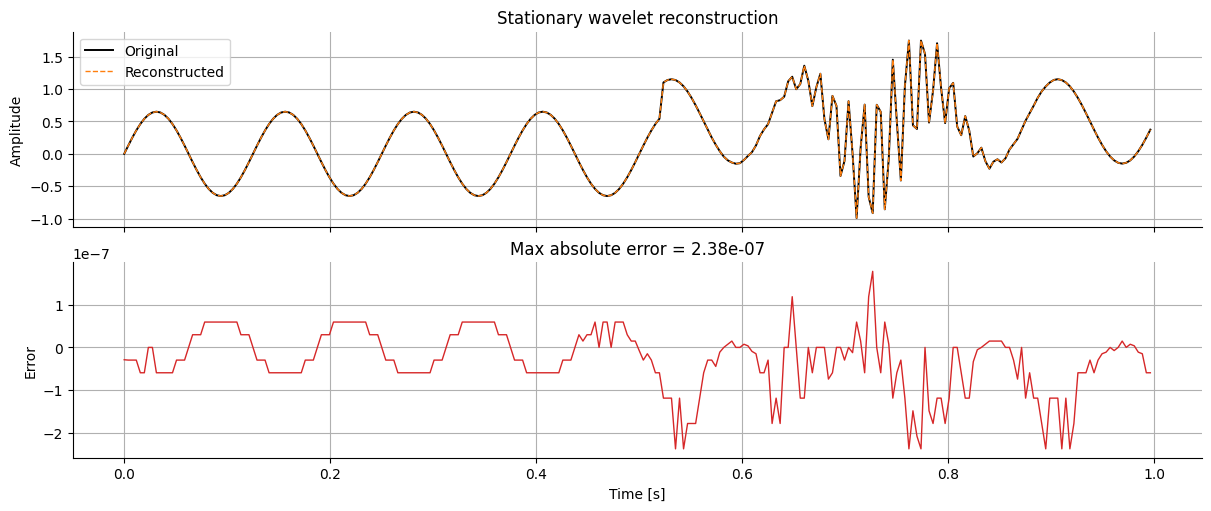

In [6]:
swt = fcwt2.StationaryWaveletTransform(4)
swt_coefficients = swt.decompose(signal.tolist())
swt_levels = swt_coefficients.levels()

fig, axes = plt.subplots(
    len(swt_levels), 2, figsize=(12, 8), sharex=True, constrained_layout=True
)
for index, level in enumerate(swt_levels, start=1):
    axes[index - 1, 0].plot(t, level.approximation, color="tab:blue")
    axes[index - 1, 0].set(
        ylabel=f"L{index}", title="Approximation" if index == 1 else None
    )
    axes[index - 1, 1].plot(t, level.detail, color="tab:purple")
    axes[index - 1, 1].set(title="Detail" if index == 1 else None)
axes[-1, 0].set_xlabel("Time [s]")
axes[-1, 1].set_xlabel("Time [s]")
plt.show()

swt_reconstructed = np.asarray(swt.reconstruct(swt_coefficients), dtype=float)
plot_reconstruction(signal, swt_reconstructed, "Stationary wavelet")

### Shift-invariance check

With periodic boundary handling, circularly shifting the input should circularly shift the SWT coefficients by the same amount. The overlay below compares one detail band after shifting it back.

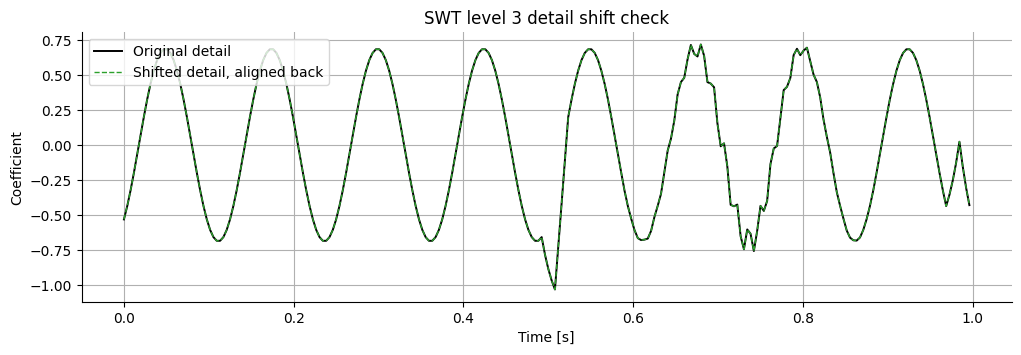

Max aligned detail error: 0.00e+00


In [7]:
shift = 17
shifted_signal = np.roll(signal, shift)
shifted_coefficients = swt.decompose(shifted_signal.tolist())

level_index = 2
detail = np.asarray(swt_coefficients.levels()[level_index].detail, dtype=float)
shifted_detail = np.asarray(
    shifted_coefficients.levels()[level_index].detail, dtype=float
)
aligned_shifted_detail = np.roll(shifted_detail, -shift)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(t, detail, color="black", lw=1.4, label="Original detail")
ax.plot(
    t,
    aligned_shifted_detail,
    color="tab:green",
    lw=1.0,
    ls="--",
    label="Shifted detail, aligned back",
)
ax.set(
    title=f"SWT level {level_index + 1} detail shift check",
    xlabel="Time [s]",
    ylabel="Coefficient",
)
ax.legend(loc="upper left")
plt.show()

print(f"Max aligned detail error: {max_abs_error(detail, aligned_shifted_detail):.2e}")

## Dual-tree complex wavelet transform

The DT-CWT returns real lowpass coefficients and complex highpass bands. Magnitude shows where a band is active; phase keeps local oscillation/timing information.

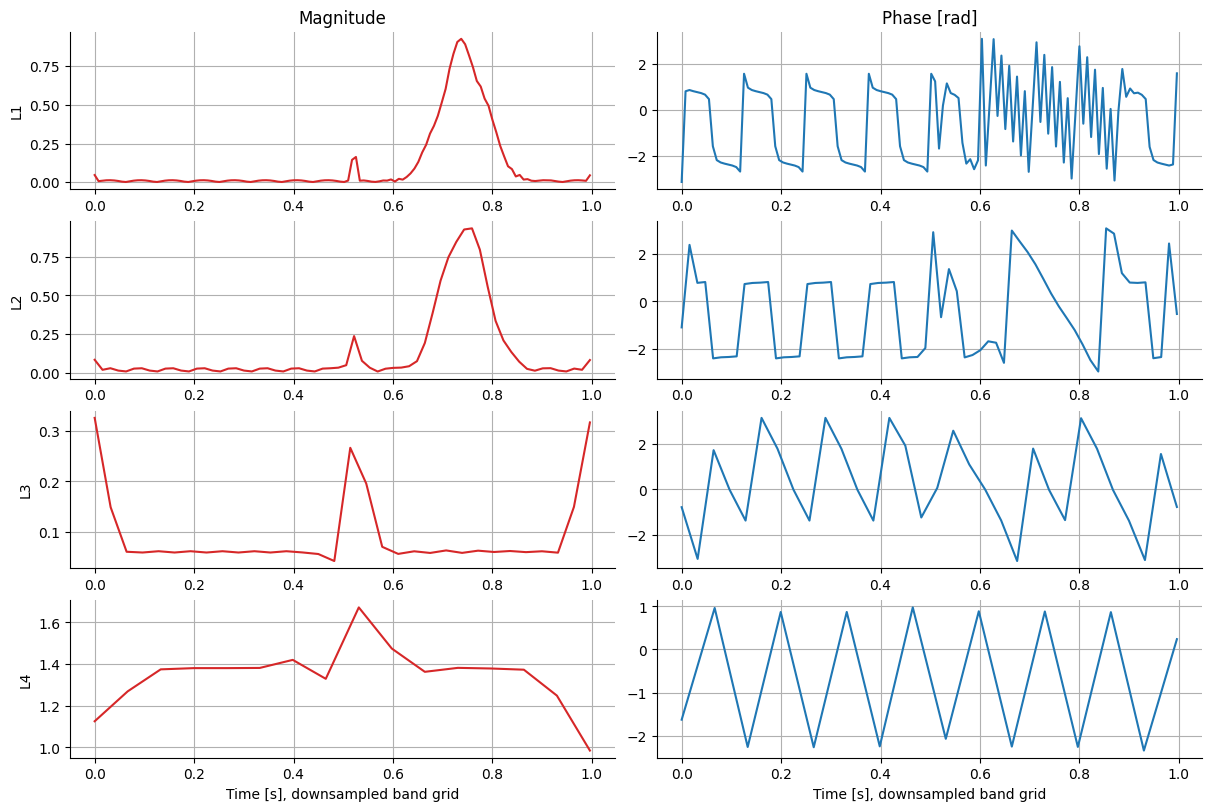

<class 'complex'> (-0.04664548113942146-0.0009227701229974627j)


In [8]:
dtcwt = fcwt2.DualTreeComplexWaveletTransform(4)
dtcwt_tree = dtcwt.decompose(signal.tolist())
dtcwt_highpasses = dtcwt_tree.highpasses()

dtcwt_magnitudes = [
    np.abs(np.asarray(level.detail, dtype=np.complex64)) for level in dtcwt_highpasses
]
dtcwt_phases = [
    np.angle(np.asarray(level.detail, dtype=np.complex64)) for level in dtcwt_highpasses
]

fig, axes = plt.subplots(
    len(dtcwt_highpasses), 2, figsize=(12, 8), constrained_layout=True
)
for index, (magnitude, phase) in enumerate(
    zip(dtcwt_magnitudes, dtcwt_phases), start=1
):
    x = np.linspace(0.0, t[-1], magnitude.size)
    axes[index - 1, 0].plot(x, magnitude, color="tab:red")
    axes[index - 1, 0].set(
        ylabel=f"L{index}", title="Magnitude" if index == 1 else None
    )
    axes[index - 1, 1].plot(x, phase, color="tab:blue")
    axes[index - 1, 1].set(title="Phase [rad]" if index == 1 else None)
axes[-1, 0].set_xlabel("Time [s], downsampled band grid")
axes[-1, 1].set_xlabel("Time [s], downsampled band grid")
plt.show()

print(type(dtcwt_highpasses[0].detail[0]), dtcwt_highpasses[0].detail[0])

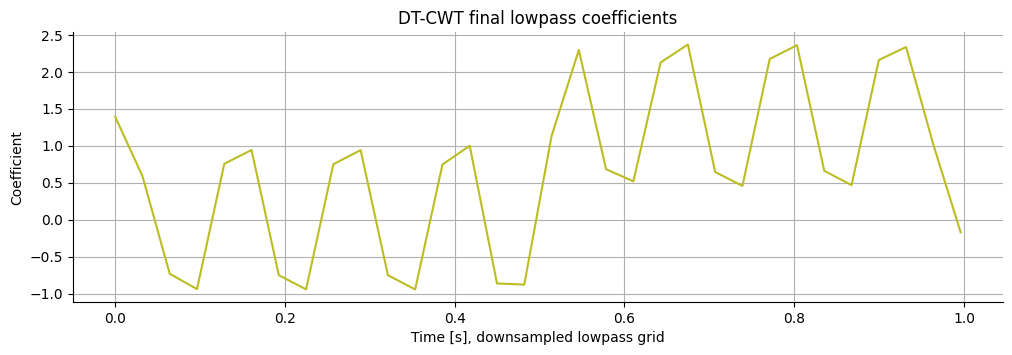

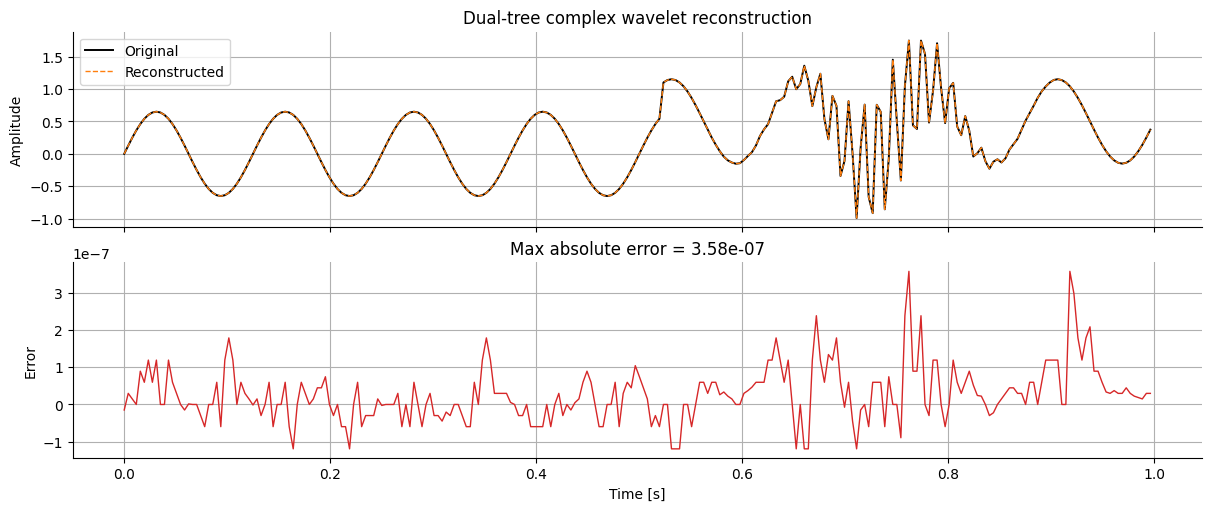

In [9]:
lowpass = np.asarray(dtcwt_tree.lowpass, dtype=float)
lowpass_x = np.linspace(0.0, t[-1], lowpass.size)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(lowpass_x, lowpass, color="tab:olive", lw=1.5)
ax.set(
    title="DT-CWT final lowpass coefficients",
    xlabel="Time [s], downsampled lowpass grid",
    ylabel="Coefficient",
)
plt.show()

dtcwt_reconstructed = np.asarray(dtcwt.reconstruct(dtcwt_tree), dtype=float)
plot_reconstruction(signal, dtcwt_reconstructed, "Dual-tree complex wavelet")

## Practical checklist

- Use power-of-two input lengths for these APIs.
- Wavelet packets are compact and tree-structured; inspect packet paths to interpret the leaves.
- SWT coefficients keep the original signal length at every level, which is handy for event localization.
- DT-CWT highpass bands are complex: plot magnitude for activity and phase for timing/oscillation structure.
- Always verify reconstruction error when building a processing pipeline around transformed coefficients.